In [33]:
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from tqdm import tqdm
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from pyspark.sql.functions import pandas_udf
import pyspark.sql.functions as F
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
import findspark
from rdkit.Chem import rdFingerprintGenerator,DataStructs 

import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score


import sys
sys.modules.pop("functionality.prediction", None)
from functionality.prediction import Predictor

sys.modules.pop("functionality.data_preparation", None)
from functionality.data_preparation import prepare_dataloaders, train_model, train_gbt

sys.modules.pop("functionality.models", None)
from functionality.models import CNNBinaryClassifierLightning, ChemBertaBinaryClassifierLightning, MolLlamaBinaryClassifierLightning, MolFormerXLBinaryClassifierLightning


In [ ]:
spark.stop()

In [2]:
findspark.init()

In [3]:
spark = SparkSession.builder\
    .appName("Molecule Analysis")\
    .config("spark.executor.memory", "22g")\
    .config("spark.driver.memory", "16g")\
    .config("spark.memory.fraction", "0.7")\
    .config("spark.memory.storageFraction", "0.4")\
    .config("spark.network.timeout", "1200s")\
    .config("spark.executor.heartbeatInterval", "200s")\
    .config("spark.sql.broadcastTimeout", "1500s")\
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.execution.arrow.maxRecordsPerBatch", "1000")\
    .getOrCreate()

25/02/20 10:19:48 WARN Utils: Your hostname, user-ThinkPad-E15-Gen-2 resolves to a loopback address: 127.0.1.1; using 10.202.33.187 instead (on interface wlp0s20f3)
25/02/20 10:19:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/02/20 10:19:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
filename = "leash-BELKA/train.parquet"
data = spark.read.parquet(filename)

data.printSchema()

data.show(5)

root
 |-- id: long (nullable = true)
 |-- buildingblock1_smiles: string (nullable = true)
 |-- buildingblock2_smiles: string (nullable = true)
 |-- buildingblock3_smiles: string (nullable = true)
 |-- molecule_smiles: string (nullable = true)
 |-- protein_name: string (nullable = true)
 |-- binds: long (nullable = true)

+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
| id|buildingblock1_smiles|buildingblock2_smiles|buildingblock3_smiles|     molecule_smiles|protein_name|binds|
+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
|  0| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|        BRD4|    0|
|  1| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         HSA|    0|
|  2| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         sEH|    0|
|  3|

In [13]:
binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(21000)
binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(2979000)

sampled_data = binds_0_sampled.union(binds_1_sampled)

sampled_data.groupBy("binds").count().show()

+-----+-------+
|binds|  count|
+-----+-------+
|    0|2979000|
|    1|  21000|
+-----+-------+



In [14]:
desc_schema = StructType([
    StructField("mol_wt", DoubleType(), True)
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    mw = mols.apply(lambda mol: round(Descriptors.MolWt(mol), 3) if mol else None)


    return pd.DataFrame({'mol_wt': mw})
    
sampled_data_with_desc = sampled_data.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

In [16]:
selected_columns = [
    "id",
    col("block1.mol_wt").alias("block1_mol_wt"),
    col("block3.mol_wt").alias("block3_mol_wt"),
    "binds",
    ]

flattened_data = sampled_data_with_desc.select(*selected_columns)

desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

In [22]:
num_bins = 30

# Create bins based on molecular weight
sampled_data_with_features = sampled_data_with_features.withColumn(
    "desc_bin", ntile(num_bins).over(Window.orderBy(col("features")))
)

In [26]:
bin_counts = sampled_data_with_features.groupBy("desc_bin", "binds").count()

# Pivot the table so each bin has counts for binds=0 and binds=1
bin_counts_pivot = bin_counts.groupBy("desc_bin").pivot("binds").sum("count").fillna(0)
bin_counts_pivot = bin_counts_pivot.withColumnRenamed("0", "count_binds_0").withColumnRenamed("1", "count_binds_1")

# Compute fraction to downsample binds=0 to match a 3:1 ratio
bin_counts_pivot = bin_counts_pivot.withColumn(
    "fraction_binds_0",
    (col("count_binds_1") * 3) / col("count_binds_0")  )


In [ ]:
fractions = bin_counts_pivot.select("desc_bin", "fraction_binds_0").rdd.collectAsMap()

binds_0_sampled = sampled_data_with_features.filter(col("binds") == 0).sampleBy("desc_bin", fractions, seed=42)

# Keep 
# all binds=1 (since it’s the minority class)
binds_1 = sampled_data_with_features.filter(col("binds") == 1)

# Merge sampled binds=0 with all binds=1
balanced_data = binds_1.unionByName(binds_0_sampled.select(binds_1.columns))

In [28]:
balanced_data.printSchema()

root
 |-- id: long (nullable = true)
 |-- binds: long (nullable = true)
 |-- features: vector (nullable = true)
 |-- desc_bin: integer (nullable = false)



In [ ]:
balanced_data.write.save("./intermediates/balanced_data_3_mln", format="parquet", mode='overwrite')

In [9]:
balanced_data = pd.read_parquet("./intermediates/balanced_data_3_mln")
balanced_ids = set(balanced_data["id"].unique())
balanced_ids_list = list(balanced_ids)

data_filtered = data.filter(data.id.isin(balanced_ids_list))

In [11]:
data_filtered.write.save("./intermediates/final_data_3_mln", format="parquet", mode='overwrite')

25/02/13 10:38:16 WARN DAGScheduler: Broadcasting large task binary with size 1784.5 KiB


In [12]:
del balanced_data
del data_filtered
del data

In [89]:
final_data = pd.read_parquet("./intermediates/final_data_3_mln")

In [ ]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=700, useBondTypes=True, includeChirality=True, includeRingMembership=True)

def compute_fn(smiles):
        
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(700, dtype=np.int8)
        
        ao = rdFingerprintGenerator.AdditionalOutput()
        ao.AllocateBitInfoMap()
        
        
        fp = fpg.GetCountFingerprint(mol, additionalOutput=ao)

        bit_info = ao.GetBitInfoMap()
        arr = np.zeros(700, dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
    
        return arr, bit_info


results = final_data['molecule_smiles'].apply(compute_fn)
final_data['fp'] = results.apply(lambda x: x[0])
bit_infos = results.apply(lambda x: x[1]).tolist()
protein_dummies = pd.get_dummies(final_data['protein_name'], prefix='protein', dtype = 'int')
final_data.drop(['molecule_smiles', 'buildingblock1_smiles', 'buildingblock2_smiles', 'buildingblock3_smiles'], axis=1, inplace=True)
fingerprint_df = pd.DataFrame(final_data["fp"].to_list(), index=final_data.index)
final_data = pd.concat([final_data.drop(columns=["fp", "protein_name"]), fingerprint_df, protein_dummies], axis=1)

feature_cols = [col for col in final_data.columns if col not in ['id', 'binds']]

X = final_data[feature_cols]
y = final_data['binds']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lgb_cls = LGBMClassifier()
lgb_cls.fit(X_train, y_train)

y_pred = lgb_cls.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

In [65]:
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)  

y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

Accuracy: 0.9231, F1: 0.8364, Precision: 0.8901, Recall: 0.7888


In [66]:
file_name = "xgb.pkl"

pickle.dump(xgb_model, open(file_name, "wb"))

In [ ]:
balanced_data = pd.read_parquet("./intermediates/balanced_data_3_mln")
balanced_ids = set(balanced_data["id"].unique())
balanced_ids_list = list(balanced_ids)

data_filtered = data.filter(~F.col("id").isin(balanced_ids_list))

binds_0_sampled = data_filtered.filter(F.col("binds") == 0).orderBy(F.rand()).limit(20000)
binds_1_sampled = data_filtered.filter(F.col("binds") == 1).orderBy(F.rand()).limit(2000)

sampled_data = binds_0_sampled.union(binds_1_sampled)

In [ ]:
sampled_data = sampled_data.toPandas()

25/02/13 10:49:01 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/02/13 10:49:01 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/02/13 10:50:27 WARN DAGScheduler: Broadcasting large task binary with size 6.3 MiB


XGBCLASSIFIER

In [71]:
sampled_data.to_parquet('sampled_data.parquet')

In [73]:
predictor = Predictor(sampled_data.drop('binds', axis = 1))
y_pred, y_pred_prob, data, bit_infos = predictor.predict()

In [74]:
y_true = sampled_data['binds']

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

Accuracy: 0.9528, F1: 0.7492, Precision: 0.7250, Recall: 0.7750


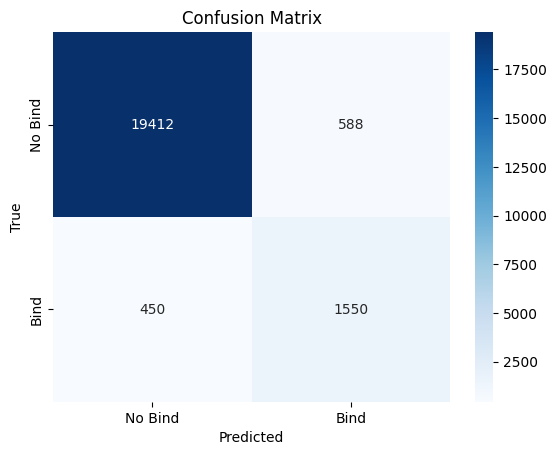

In [75]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

LIGHTGBM

In [91]:
file_name = "lgb_cls.pkl"

pickle.dump(lgb_cls, open(file_name, "wb"))

In [77]:
predictor = Predictor(sampled_data.drop('binds', axis = 1))
y_pred, y_pred_prob, data, bit_infos = predictor.predict()

In [78]:
predictor = Predictor(sampled_data.drop('binds', axis = 1))
y_pred, y_pred_prob, data, bit_infos = predictor.predict()

y_true = sampled_data['binds']

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}')

Accuracy: 0.9544, F1: 0.7505, Precision: 0.7460, Recall: 0.7550


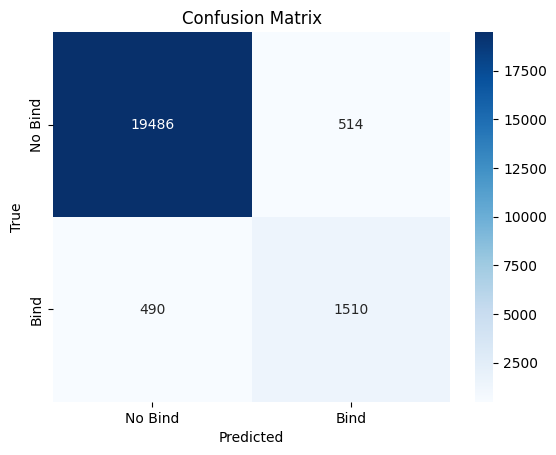

In [79]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [42]:
test = pd.read_parquet('./leash-BELKA/test.parquet')

In [ ]:

batch_size = 10000
n_batches = len(test) // batch_size + (1 if len(test) % batch_size != 0 else 0)

y_pred_prob_list = []

with tqdm(total=n_batches, desc="Processing batches") as pbar:
   
    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, len(test))
         
        test_batch = test.iloc[start_idx:end_idx]
        
        print(f"Processing batch {batch_idx + 1}/{n_batches}, rows {start_idx} to {end_idx}")
        
        predictor = Predictor(test_batch)
        _, y_pred_prob, _, _ = predictor.predict()
        
        y_pred_prob_list.append(y_pred_prob[:, 1])
        
        pbar.update(1)
        
        print(f"Batch {batch_idx + 1} completed.")

y_pred_all = np.concatenate(y_pred_prob_list, axis=0)

In [51]:
test[['id', 'binds']].to_csv('submission.csv', index=False)

10 to 1 ratio

In [66]:
binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(10000000)

binds_0_sampled.show()

+---------+---------------------+---------------------+---------------------+--------------------+------------+-----+
|       id|buildingblock1_smiles|buildingblock2_smiles|buildingblock3_smiles|     molecule_smiles|protein_name|binds|
+---------+---------------------+---------------------+---------------------+--------------------+------------+-----+
|154734647| O=C(Nc1c(OC(F)(F)...| CC(C)(C)OC(=O)n1n...| CC(C)(C)OC(=O)N1C...|CC(C)(C)OC(=O)N1C...|         sEH|    0|
| 30864732| COc1cc(C(=O)O)c(N...|       Cc1cc(N)ccc1Cl|            CCSCCN.Cl|CCSCCNc1nc(Nc2ccc...|        BRD4|    0|
| 84912873| O=C(NCc1cccc(C(=O...| Nc1nc(-c2ccc(F)cc...|    Cc1ccc(CN)c(Cl)n1|Cc1ccc(CNc2nc(NCc...|        BRD4|    0|
|115130806| O=C(N[C@H](C(=O)O...|         NCC1(O)CCSC1| NCc1cccc(C(=O)N2C...|O=C(N[Dy])[C@@H](...|         HSA|    0|
|214078756| O=C(Nc1cccc(I)c1C...|   Cl.N#Cc1ccc(CN)nc1| NCc1ccc(Oc2cccnc2...|N#Cc1ccc(CNc2nc(N...|         HSA|    0|
|222050752| O=C(Nc1cnccc1C(=O...|  Nc1ccc(-n2cccc2)cc1| 

In [69]:
desc_schema = StructType([
    StructField("tpsa", DoubleType(), True)
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    tpsa = mols.apply(lambda mol: round(Descriptors.TPSA(mol), 3) if mol else None)


    return pd.DataFrame({'tpsa': tpsa})
    
sampled_data_with_desc = binds_0_sampled.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

In [70]:
selected_columns = [
    "id",
    col("block1.tpsa").alias("block1_tpsa"),
    col("block3.tpsa").alias("block3_tpsa"),
    "binds",
    ]

flattened_data = sampled_data_with_desc.select(*selected_columns)

desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "features")

In [71]:
num_bins = 20

# Create bins based on molecular weight
windowSpec = Window.orderBy("features")
sampled_data = sampled_data_with_features.withColumn(
    "desc_bin", ntile(num_bins).over(windowSpec)
)

In [ ]:
# Add row numbers within each bin
bin_window = Window.partitionBy("desc_bin").orderBy(rand())  # Randomize order
sampled_data = sampled_data.withColumn("row_num", row_number().over(bin_window))

# Keep only 100,000 rows per bin
sample_size = 100000
downsampled_data = sampled_data.filter(col("row_num") <= sample_size).drop("row_num")
binds_0_id = downsampled_data.select(col('id')).toPandas().cache()

In [36]:
binds_0_id.to_csv('binds_0_id.csv', index = False)

In [5]:
binds_0_id = pd.read_csv('binds_0_id.csv')
binds_0_id.head()

,id
0,232877885
1,240173612
2,7175820
3,240645766
4,290400610


In [6]:
# Final datasetdata_filtered = data.filter(data.id.isin(binds_0_id.id.values.tolist()))
data_filtered = data.filter(data.id.isin(binds_0_id.id.values.tolist()))

In [8]:
data_filtered.write.save("./intermediates/downsampled_0_10_mln", format="parquet", mode='overwrite')

25/02/16 11:52:40 WARN DAGScheduler: Broadcasting large task binary with size 36.5 MiB


In [3]:
binds_0 = pd.read_parquet("./intermediates/downsampled_0_10_mln")
binds_1 = pd.read_parquet("./intermediates/1_class")

In [4]:
final_data = pd.concat([binds_0, binds_1], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
del binds_1
del binds_0
final_data.shape

(3589906, 7)

In [5]:
train, test = train_test_split(final_data, test_size=0.2, random_state=42)
del final_data

In [33]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024, includeChirality=True)

def compute_fps(smiles_batch):

    """
    Compute fingerprints for a batch of SMILES
    """
    results = []
    for smiles in smiles_batch:
        mol = Chem.MolFromSmiles(smiles.replace('[Dy]', '[H]'))
        if mol is None:
            results.append((np.zeros(1024, dtype=np.int8), {}))
        else:
            ao = rdFingerprintGenerator.AdditionalOutput()
            ao.AllocateBitInfoMap()
            fp = fpg.GetCountFingerprint(mol, additionalOutput=ao)
            arr = np.zeros(1024, dtype=np.int8)
            DataStructs.ConvertToNumpyArray(fp, arr)
            results.append((arr, ao.GetBitInfoMap()))
    return zip(*results)

all_protein_names = train['protein_name'].unique().tolist()

batch_size = 100000
smiles_batches = np.array_split(train['molecule_smiles'].tolist(), -(-len(train) // batch_size))
protein_batches = np.array_split(train['protein_name'].tolist(), -(-len(train) // batch_size))
label_batches = np.array_split(train['binds'].tolist(), -(-len(train) // batch_size))


lgb_cls = LGBMClassifier(objective='binary', verbose=-1, warm_start=True)

for smiles_batch, protein_batch, label_batch in tqdm(zip(smiles_batches, protein_batches, label_batches), total=len(smiles_batches), desc="Training Model in Batches"):

    if len(smiles_batch) != len(label_batch):
        continue

    fps, _ = compute_fps(smiles_batch)
    X_batch = pd.DataFrame(fps)
    
    protein_df = pd.get_dummies(pd.Series(protein_batch), prefix='protein', dtype=np.uint8)
    protein_df = protein_df.reindex(columns=[f'protein_{p}' for p in all_protein_names], fill_value=0)
    
    
    X_batch = pd.concat([X_batch, protein_df], axis=1)
    y_batch = np.array(label_batch)
    
    lgb_cls.fit(X_batch, y_batch, init_model=lgb_cls.booster_ if hasattr(lgb_cls, "booster_") else None)

Training Model in Batches:   0%|          | 0/29 [00:00<?, ?it/s]ERROR:root:Exception while sending command.
Traceback (most recent call last):
  File "/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/py4j/clientserver.py", line 516, in send_command
    raise Py4JNetworkError("Answer from Java side is empty")
py4j.protocol.Py4JNetworkError: Answer from Java side is empty

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/py4j/clientserver.py", line 539, in send_command
    raise Py4JNetworkError(
py4j.protocol.Py4JNetworkError: Error while sending or receiving
Training Model in Batches: 100%|██████████| 29/29 [50:58<00:00, 105.46s/it] 


In [72]:
smiles_batches = np.array_split(test['molecule_smiles'].tolist(), -(-len(test) // batch_size))
protein_batches = np.array_split(test['protein_name'].tolist(), -(-len(test) // batch_size))

y_pred_list = []
y_pred_proba_list = []

for smiles_batch, protein_batch in tqdm(zip(smiles_batches, protein_batches), total=len(smiles_batches), desc="Prediction on Test Set"):

    fps, _ = compute_fps(smiles_batch)

    X_batch = pd.DataFrame(fps)
    
    protein_df = pd.get_dummies(pd.Series(protein_batch), prefix='protein', dtype=np.uint8)
    protein_df = protein_df.reindex(columns=[f'protein_{p}' for p in all_protein_names], fill_value=0)
    
    X_batch = pd.concat([X_batch, protein_df], axis=1)

    y_pred = lgb_cls.predict(X_batch)
    y_pred_proba = lgb_cls.predict_proba(X_batch)

    y_pred_list.append(y_pred)
    y_pred_proba_list.append(y_pred_proba[:, 1])

y_test = test['binds'].to_list()

y_pred_list = np.concatenate(y_pred_list)
y_pred_proba_list = np.concatenate(y_pred_proba_list)

accuracy = accuracy_score(y_test, y_pred_list)
f1 = f1_score(y_test, y_pred_list)
recall = recall_score(y_test, y_pred_list)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}, Recall: {recall:.4f}')


Prediction on Test Set: 100%|██████████| 8/8 [12:12<00:00, 91.53s/it]


Accuracy: 0.9287, F1: 0.9190, Recall: 0.9129


In [34]:
file_name = "lgb_cls_10_mln.pkl"

pickle.dump(lgb_cls, open(file_name, "wb"))

Score: 0.31224
Private score: 0.18767

In [23]:
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024, includeChirality=True)

def compute_fps(smiles_batch):

    """
    Compute fingerprints for a batch of SMILES
    """
    results = []
    for smiles in smiles_batch:
        mol = Chem.MolFromSmiles(smiles.replace('[Dy]', '[H]'))
        if mol is None:
            results.append((np.zeros(1024, dtype=np.int8), {}))
        else:
            fp = fpg.GetCountFingerprint(mol)
            arr = np.zeros(1024, dtype=np.int8)
            DataStructs.ConvertToNumpyArray(fp, arr)
            results.append(arr)
    return np.array(results)

def train_model_for_protein(protein_data, batch_size=100000, lgb_params = None, eval_set = None):
    smiles_batches = np.array_split(protein_data['molecule_smiles'].tolist(), -(-len(protein_data) // batch_size))
    label_batches = np.array_split(protein_data['binds'].tolist(), -(-len(protein_data) // batch_size))
    if eval_set:
        eval_features = compute_fps(eval_set['molecule_smiles'])
        eval_labels = eval_set['binds']

    # Initialize the LightGBM classifier with the parameters
    lgb_cls = LGBMClassifier(**lgb_params)


    for smiles_batch, label_batch in tqdm(zip(smiles_batches, label_batches), total=len(smiles_batches), desc=f"Training {protein_data['protein_name'].unique()}"):
        if len(smiles_batch) != len(label_batch):
            continue
        
        X_batch = compute_fps(smiles_batch)
        y_batch = np.array(label_batch)

        lgb_cls.fit(X_batch, y_batch, eval_set=[(eval_features, eval_labels)] if eval_set else None, eval_metric='auc', init_model=lgb_cls.booster_ if hasattr(lgb_cls, "booster_") else None)

    return lgb_cls

def save_models(model, protein, save_dir="./checkpoints"):
    os.makedirs(save_dir, exist_ok=True)

    model_path = os.path.join(save_dir, f"{protein}_lightgbm.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"Model for {protein} saved at {model_path}")

def train_models_by_protein(train_df, batch_size=100000, save_dir="./checkpoints", lgb_params = None, eval_set = None):
    all_protein_names = train_df['protein_name'].unique()

    for protein in tqdm(all_protein_names, desc="Training models"):
        protein_data = train_df[train_df['protein_name'] == protein]
        if eval_set:
            eval_set = eval_set.copy()
            eval_set = eval_set[eval_set['protein_name'] == protein]
        
        model = train_model_for_protein(protein_data, batch_size, lgb_params, eval_set)

        
        save_models(model, protein, save_dir)

    return "Training complete"


In [ ]:
train_models_by_protein(train)

In [18]:
def load_model(protein, output_dir="./intermediates/models"):
    model_path = os.path.join(output_dir, f"{protein}.pkl")
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    return model


def predict_for_batch(smiles_batch, model):
    """
    Predicts for a batch of SMILES based on the corresponding protein models
    
    Args:
        smiles_batch (list): List of SMILES strings for the current batch
        model: preloaded model for each protein

    Returns:
        y_pred_proba_list (list): Predicted probabilities for the current batch
    """
    
    
    X_batch = compute_fps(smiles_batch)
    
    y_pred_proba = model.predict_proba(X_batch)[:, 1] 
    
    return y_pred_proba


def predict(test_df, batch_size=100000, output_dir="./intermediates/models"):
    y_pred_proba_list = []
    ids_list = []  

    all_protein_names = test_df['protein_name'].unique()

    for protein in tqdm(all_protein_names, desc="Predicting for all proteins"):
        protein_data = test_df[test_df['protein_name'] == protein]
        model = load_model(protein, output_dir)
        
        smiles_batches = np.array_split(protein_data['molecule_smiles'].tolist(), -(-len(protein_data) // batch_size))
        ids_batches = np.array_split(protein_data['id'].tolist(), -(-len(protein_data) // batch_size))

        for smiles_batch, ids_batch in tqdm(zip(smiles_batches, ids_batches), total=len(smiles_batches), desc=f"Prediction for {protein}"):

            y_pred_proba = predict_for_batch(smiles_batch, model)
            
            y_pred_proba_list.append(y_pred_proba)
            ids_list.append(ids_batch)  

    y_pred_proba_list = np.concatenate(y_pred_proba_list)
    ids_list = np.concatenate(ids_list)

    result_df = pd.DataFrame({'id': ids_list, 'prediction': y_pred_proba_list})
    result_df = result_df.sort_values(by='id')

    result_df.to_csv('./predictions.csv', index=False)

    return result_df

In [ ]:
test = pd.read_parquet('./leash-BELKA/test.parquet') 
predictions = predict(test)

Score: 0.28753
Private score: 0.15467

**SELECT ONLY FULLY NEGATIVE SAMPLES FOR CLASS 0**

In [4]:
filename = "leash-BELKA/train.parquet"
data = spark.read.parquet(filename)
data.printSchema()

root
 |-- id: long (nullable = true)
 |-- buildingblock1_smiles: string (nullable = true)
 |-- buildingblock2_smiles: string (nullable = true)
 |-- buildingblock3_smiles: string (nullable = true)
 |-- molecule_smiles: string (nullable = true)
 |-- protein_name: string (nullable = true)
 |-- binds: long (nullable = true)



In [ ]:
binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(50000000)

binds_0_sampled.show()

In [ ]:
desc_schema = StructType([
    StructField("tpsa", DoubleType(), True)
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    tpsa = mols.apply(lambda mol: round(Descriptors.TPSA(mol), 3) if mol else None)


    return pd.DataFrame({'tpsa': tpsa})
    
sampled_data_with_desc = binds_0_sampled.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

selected_columns = [
    "id",
    col("block1.tpsa").alias("block1_tpsa"),
    col("block3.tpsa").alias("block3_tpsa"),
    "binds",
    ]

flattened_data = sampled_data_with_desc.select(*selected_columns)

desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "features")

num_bins = 10

windowSpec = Window.orderBy("features")
sampled_data = sampled_data_with_features.withColumn(
    "desc_bin", ntile(num_bins).over(windowSpec)
)

# Add row numbers within each bin
bin_window = Window.partitionBy("desc_bin").orderBy(rand())  # Randomize order
sampled_data = sampled_data.withColumn("row_num", row_number().over(bin_window))

# Keep only 1000000 rows per bin
sample_size = 1000000
downsampled_data = sampled_data.filter(col("row_num") <= sample_size).drop("row_num")
binds_0_id = downsampled_data.select(col('id')).toPandas()

In [8]:
filename = "leash-BELKA/train.parquet"
data = spark.read.parquet(filename)
binds_0_id_spark = spark.read.parquet('./intermediates/binds_0_id_10_mln.parquet').select("id")

data_filtered = data.join(binds_0_id_spark.hint("broadcast"), on="id", how="inner")

# Save the filtered data
data_filtered.write.mode("overwrite").parquet("./intermediates/downsampled_0_50_mln")

In [9]:
spark.stop()

In [20]:
binds_0 = pd.read_parquet("./intermediates/downsampled_0_50_mln")
binds_1 = pd.read_parquet("./intermediates/1_class")
final_data = pd.concat([binds_0, binds_1], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
del binds_1
del binds_0
final_data.shape

(11589906, 7)

In [21]:
binds_0 = pd.read_parquet("./intermediates/downsampled_0_50_mln")
binds_1 = pd.read_parquet("./intermediates/1_class")
final_data = pd.concat([binds_0, binds_1], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
del binds_1
del binds_0
final_data.shape
train, eval = train_test_split(final_data, test_size=0.05, random_state=42)
del final_data

In [ ]:
lgb_params = {
        'max_depth': 11,
        'bagging_fraction': 0.9,
        'learning_rate': 0.05,
        'colsample_bytree': 1,
        'colsample_bynode': 0.5,
        'lambda_l1': 1,
        'objective': 'binary',
        'lambda_l2': 1.5,
        'num_leaves': 490,
        'min_data_in_leaf': 50,
        'verbose': -1,
        'metric': 'average_precision',
        'device': 'cpu'
    }

train_models_by_protein(train, batch_size=100000, lgb_params=lgb_params)

In [ ]:
test = pd.read_parquet('./leash-BELKA/test.parquet') 
predictions = predict(test)

Score: 0.34215
Private score: 0.19273

In [ ]:
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 11,
    'num_leaves': 490,
    'min_data_in_leaf': 50,
    'lambda_l1': 1,
    'lambda_l2': 1.5,
    'bagging_fraction': 0.9,
    'colsample_bytree': 1,
    'colsample_bynode': 0.5,
    'verbose': -1,
    'device': 'cpu',
    'scale_pos_weight': 6.3,
    'boost_from_average': True,
    'max_delta_step': 0.7, 
}


train_models_by_protein(train, batch_size=100000, lgb_params=lgb_params)

In [ ]:
predictions = predict(test)

Score: 0.29820
Private score: 0.17553

In [6]:
binds_0 = pd.read_parquet("./intermediates/downsampled_0_50_mln")
binds_1 = pd.read_parquet("./intermediates/1_class")
final_data = pd.concat([binds_0, binds_1], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
del binds_1
del binds_0